In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm 

#### System with non fixed electron number
- 1 tube with one dot

In [2]:
def couplingstrength(mu):
    ''' Computes the coupling strength between electrons and phonons for single tube with two sites in
        guitar string limit.
    
    Parameters
    - mu: integer of corresponding phononic mode
        '''
    return (1/np.pi)*mu**(-3/2)*(1-np.cos(np.pi*mu))

In [3]:
def single_electron(l,eps,max_mu):
    E = eps
    for mu in range(1,max_mu+1):
        E -= (l/mu)*couplingstrength(mu)**2
    return E

def two_electrons(l,eps,max_mu):
    E = 1+2*eps
    for mu in range(1,max_mu+1):
        E -= (l/mu)*(couplingstrength(mu)**2*4)
    return E

100%|██████████| 200/200 [00:05<00:00, 36.32it/s]


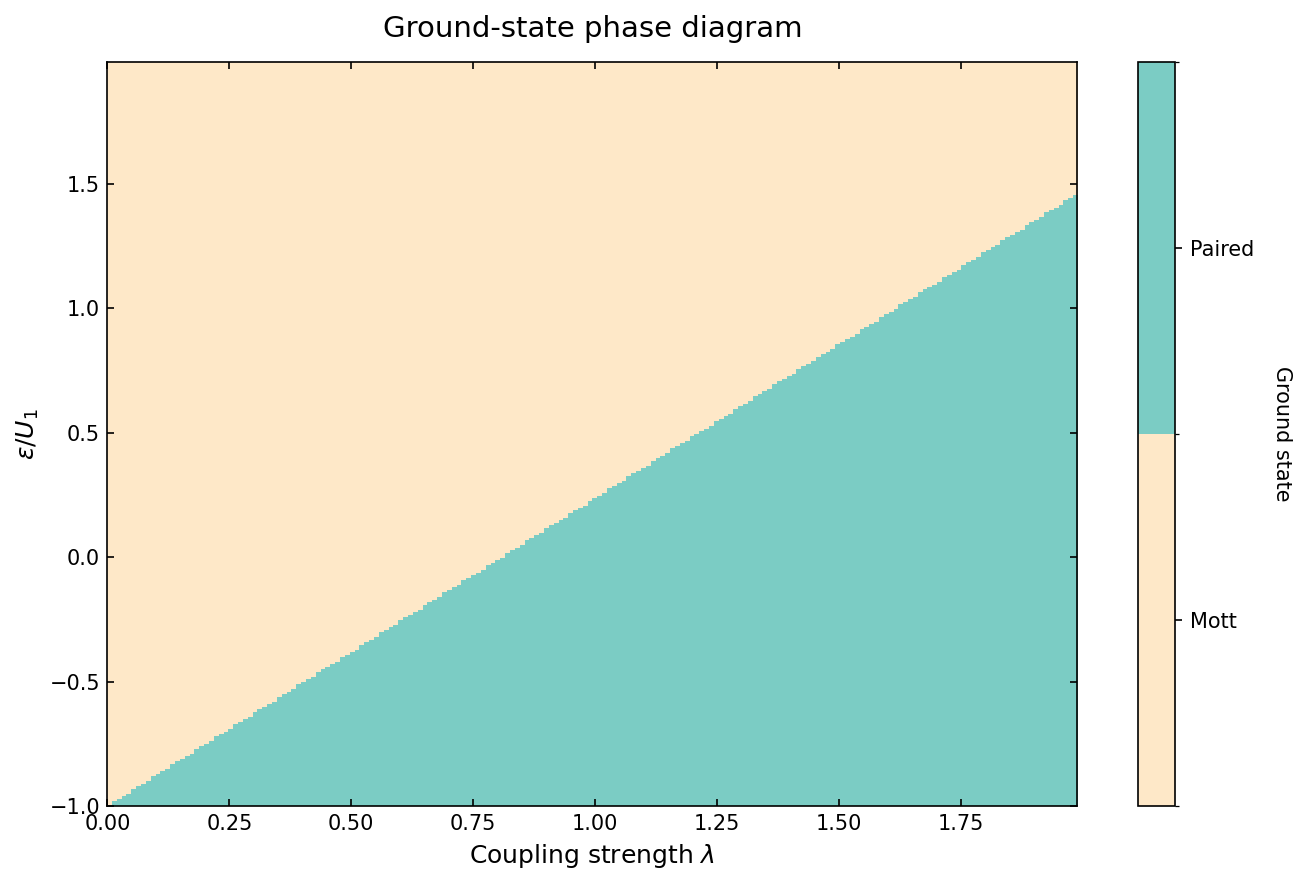

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm

# Compute energies of electronic states for different coupling strengths 
l = np.arange(0, 2, 0.01)
e = np.arange(-1, 2, 0.01)

#print(e)

max_mu = 50

energies = np.zeros((2, len(e), len(l)))
GS = np.zeros((len(e), len(l)), dtype=int)

for j, li in enumerate(tqdm(l)):
    for i, ei in enumerate(e):
        energies[0, i, j] = single_electron(li, ei, max_mu)
        energies[1, i, j] = two_electrons(li, ei, max_mu)

        GS[i, j] = np.argmin(energies[:, i, j])

# One color per phase
phase_names = [
    "Mott",
    "Paired",
]

cmap = ListedColormap([
    "#fee8c8",
    "#7bccc4",
])

# Need 6 boundaries for 5 discrete values: 0, 1, 2, 3, 4
bounds = [-0.5, 0.5, 1.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

im = ax.imshow(
    GS,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[l.min(), l.max(), e.min(), e.max()],
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(phase_names)
cbar.set_label("Ground state", rotation=270, labelpad=18)

ax.set_xlabel(r"Coupling strength $\lambda$", fontsize=12)
ax.set_ylabel(r"$\epsilon/U_1$", fontsize=12)
ax.set_title("Ground-state phase diagram", fontsize=14, pad=12)

ax.tick_params(direction="in", top=True, right=True)

plt.tight_layout()
plt.show()

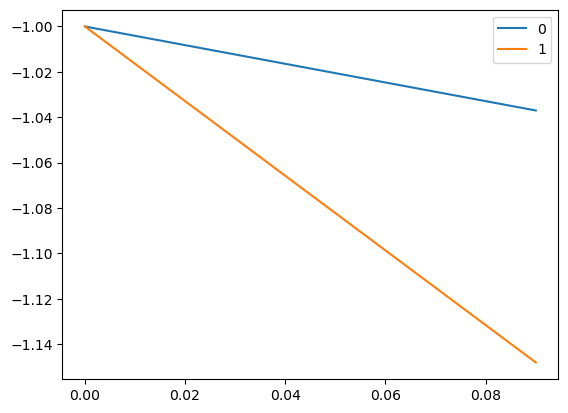

In [5]:

plt.plot(l[:10],energies[0][0][:10],label="0")
plt.plot(l[:10],energies[1][0][:10],label="1")
plt.legend()


In [6]:
def E_MottMott(l,e,max_mu,V):
    ''' Computes the energie of the Mott-Mott state of two parallel tubes with two sites and two electrons of 
        different spins.
    
    Parameters
    - l: coupling strength lambda (Lang-Firsov limit)
    - max_mu: finite value approximating the infinite sum from LF Hamiltonian
    - V: corresponding to V/U (the Coulomb coupling between the tubes)
        '''
    E = single_electron(l,e,max_mu)*2+V
    return E

def E_PairedPaired(l,e,max_mu,V):
    ''' Computes the energie of the Paired-Paired state of two parallel tubes with two sites and two electrons of 
        different spins.
    
    Parameters
    - l: coupling strength lambda (Lang-Firsov limit)
    - max_mu: finite value approximating the infinite sum from LF Hamiltonian
    - V: corresponding to V/U (the Coulomb coupling between the tubes)
        '''
    E = two_electrons(l,e,max_mu)*2+V*4
    return E

def E_MottPaired(l,e,max_mu,V):
    ''' Computes the energie of the Mott-Paired state of two parallel tubes with two sites and two electrons of 
        different spins.
    
    Parameters
    - l: coupling strength lambda (Lang-Firsov limit)
    - max_mu: finite value approximating the infinite sum from LF Hamiltonian
    - V: corresponding to V/U (the Coulomb coupling between the tubes)
        '''
    E = two_electrons(l,e,max_mu)+single_electron(l,e,max_mu)+V*2
    return E

def E_MottNoth(l,e,max_mu,V):
    ''' Computes the energie of the Mott-Paired state of two parallel tubes with two sites and two electrons of 
        different spins.
    
    Parameters
    - l: coupling strength lambda (Lang-Firsov limit)
    - max_mu: finite value approximating the infinite sum from LF Hamiltonian
    - V: corresponding to V/U (the Coulomb coupling between the tubes)
        '''
    E = single_electron(l,e,max_mu)
    return E

def E_PairedNoth(l,e,max_mu,V):
    ''' Computes the energie of the Mott-Paired state of two parallel tubes with two sites and two electrons of 
        different spins.
    
    Parameters
    - l: coupling strength lambda (Lang-Firsov limit)
    - max_mu: finite value approximating the infinite sum from LF Hamiltonian
    - V: corresponding to V/U (the Coulomb coupling between the tubes)
        '''
    E = two_electrons(l,e,max_mu)
    return E

100%|██████████| 260/260 [00:25<00:00, 10.03it/s]


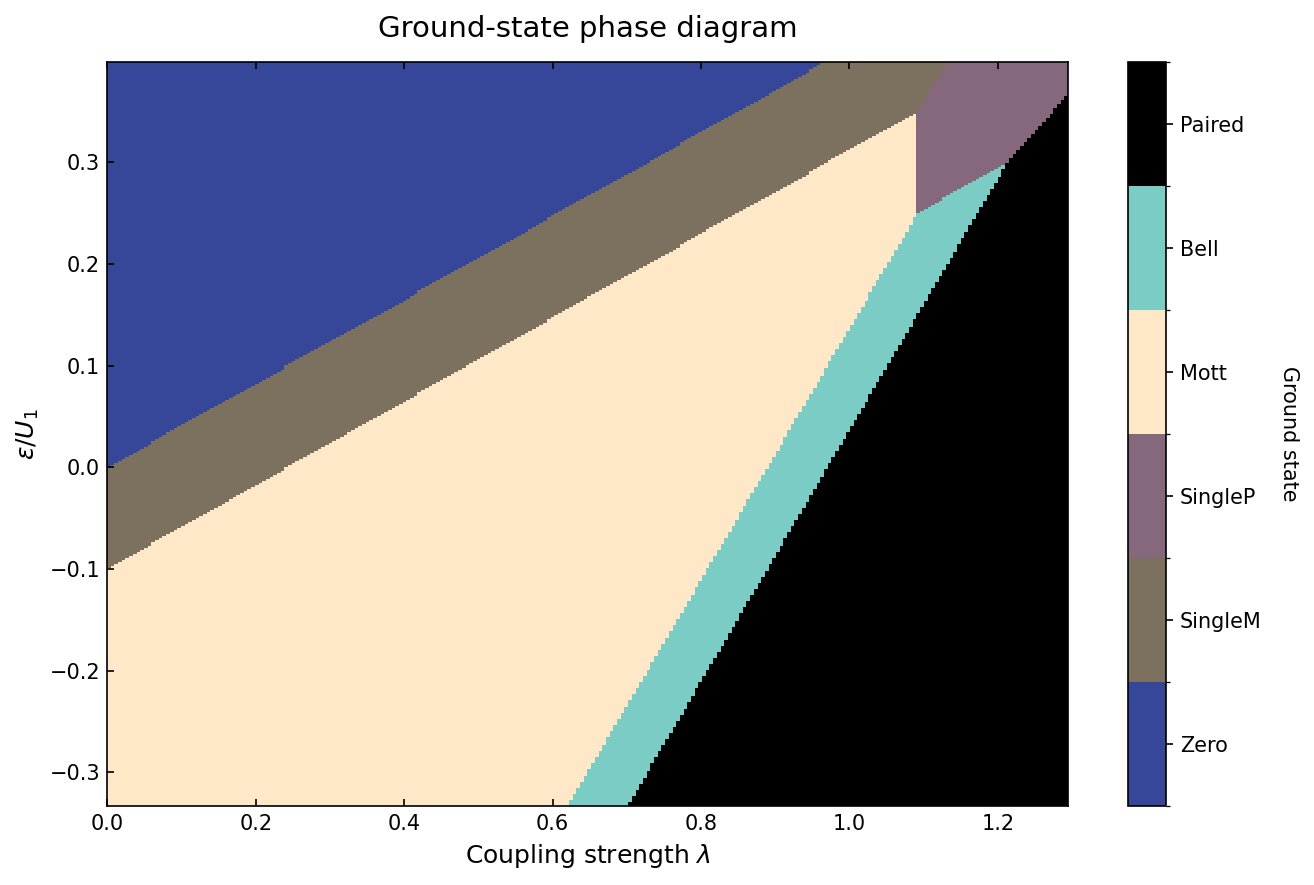

In [7]:
# Compute energies of electronic states for different coupling strengths 
l = np.arange(0, 1.3, 0.005)
e = np.arange(-1/3, 0.4, 0.002)
V = 0.1

#print(e)

max_mu = 50

energies = np.zeros((6, len(e), len(l)))
GS = np.zeros((len(e), len(l)), dtype=int)

for j, li in enumerate(tqdm(l)):
    for i, ei in enumerate(e):
        energies[0, i, j] = 0
        energies[1, i, j] = E_MottNoth(li, ei, max_mu,V)
        energies[2, i, j] = E_PairedNoth(li, ei, max_mu,V)
        energies[3, i, j] = E_MottMott(li, ei, max_mu,V)
        energies[4, i, j] = E_MottPaired(li, ei, max_mu,V)
        energies[5, i, j] = E_PairedPaired(li, ei, max_mu,V)

        GS[i, j] = np.argmin(energies[:, i, j])

# One color per phase
phase_names = [
    "Zero",
    "SingleM",
    "SingleP",
    "Mott",
    "Bell",
    "Paired",
]

cmap = ListedColormap([
    "#364799",
    "#7c705f",
    "#86687d",
    "#fee8c8",
    "#7bccc4",
    "black",
])

# Need 6 boundaries for 5 discrete values: 0, 1, 2, 3, 4
bounds = [-0.5, 0.5, 1.5,2.5,3.5,4.5,5.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

im = ax.imshow(
    GS,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[l.min(), l.max(), e.min(), e.max()],
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1,2,3,4,5])
cbar.ax.set_yticklabels(phase_names)
cbar.set_label("Ground state", rotation=270, labelpad=18)

ax.set_xlabel(r"Coupling strength $\lambda$", fontsize=12)
ax.set_ylabel(r"$\epsilon/U_1$", fontsize=12)
ax.set_title("Ground-state phase diagram", fontsize=14, pad=12)

ax.tick_params(direction="in", top=True, right=True)

plt.tight_layout()
plt.show()

100%|██████████| 434/434 [00:03<00:00, 132.85it/s]


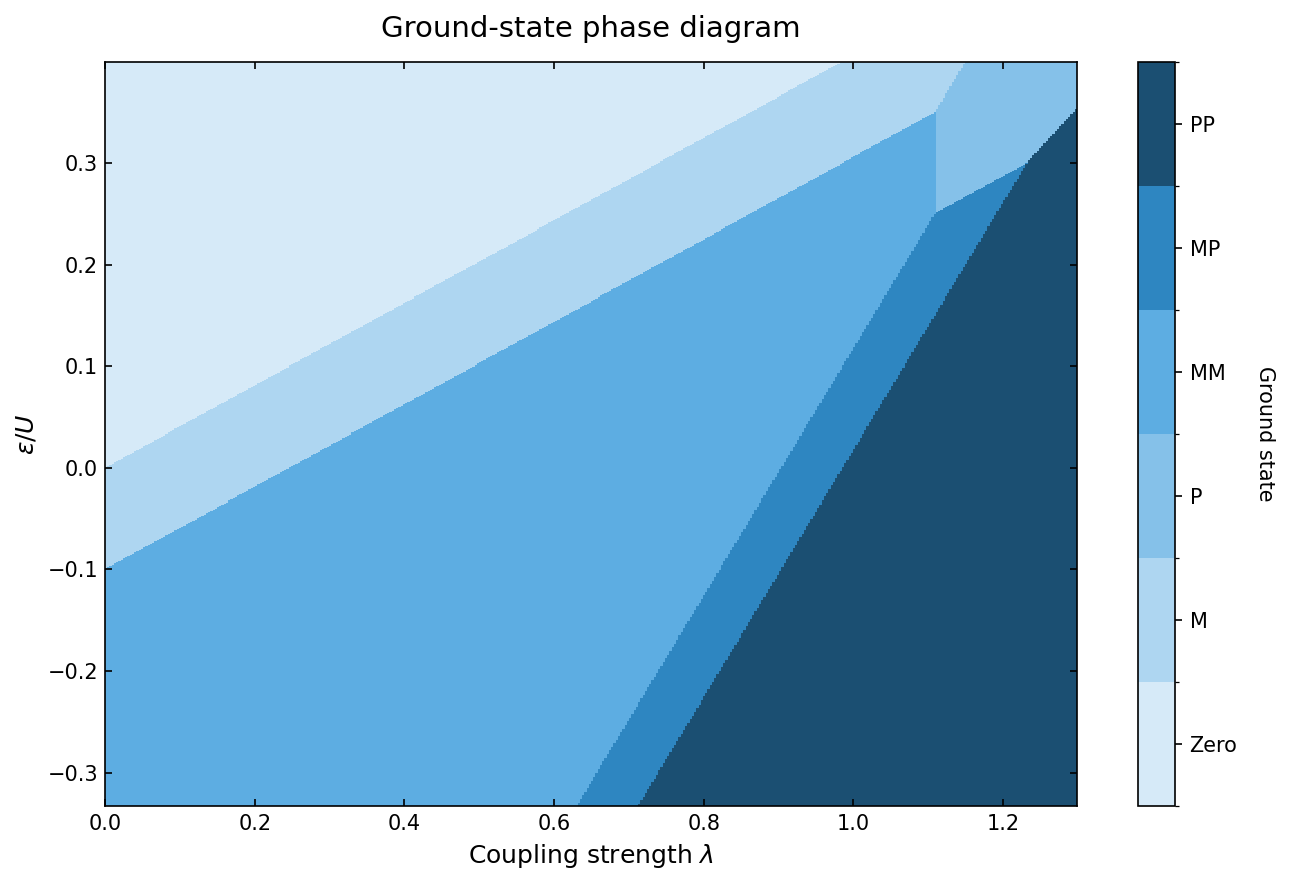

In [19]:
# Compute energies of electronic states for different coupling strengths 
l = np.arange(0, 1.3, 0.003)
e = np.arange(-1/3, 0.4, 0.001)
V = 0.1

#print(e)

max_mu = 1

energies = np.zeros((6, len(e), len(l)))
GS = np.zeros((len(e), len(l)), dtype=int)

for j, li in enumerate(tqdm(l)):
    for i, ei in enumerate(e):
        energies[0, i, j] = 0
        energies[1, i, j] = E_MottNoth(li, ei, max_mu,V)
        energies[2, i, j] = E_PairedNoth(li, ei, max_mu,V)
        energies[3, i, j] = E_MottMott(li, ei, max_mu,V)
        energies[4, i, j] = E_MottPaired(li, ei, max_mu,V)
        energies[5, i, j] = E_PairedPaired(li, ei, max_mu,V)

        GS[i, j] = np.argmin(energies[:, i, j])

# One color per phase
phase_names = [
    "Zero",
    "M",
    "P",
    "MM",
    "MP",
    "PP",
]

phase_colors = [
    "#d6eaf8",
    "#aed6f1",
    "#85c1e9",
    "#5dade2",
    "#2e86c1",
    "#1b4f72",
]
cmap = ListedColormap(phase_colors)

# Need 6 boundaries for 5 discrete values: 0, 1, 2, 3, 4
bounds = [-0.5, 0.5, 1.5,2.5,3.5,4.5,5.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(9, 6), dpi=150)

im = ax.imshow(
    GS,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    norm=norm,
    extent=[l.min(), l.max(), e.min(), e.max()],
    interpolation="nearest"
)

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1,2,3,4,5])
cbar.ax.set_yticklabels(phase_names)
cbar.set_label("Ground state", rotation=270, labelpad=18)

ax.set_xlabel(r"Coupling strength $\lambda$", fontsize=12)
ax.set_ylabel(r"$\epsilon/U$", fontsize=12)
ax.set_title("Ground-state phase diagram", fontsize=14, pad=12)

ax.tick_params(direction="in", top=True, right=True)


plt.tight_layout()
fig.savefig("phasespectrum-analytical-singlemode.png", bbox_inches='tight')

plt.show()

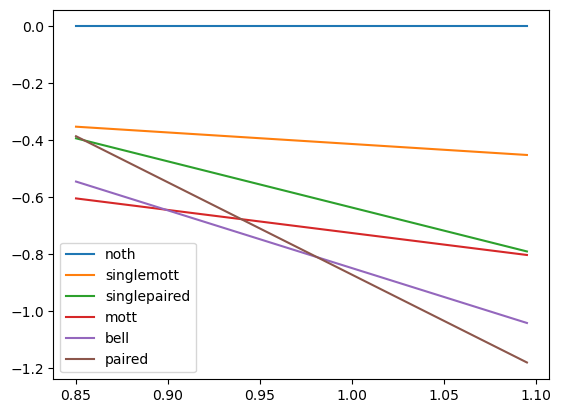

In [27]:
a = 170
b = -40
plt.plot(l[a:b],energies[0][len(e)//2-20][a:b],label="noth")
plt.plot(l[a:b],energies[1][len(e)//2-20][a:b],label="singlemott")
plt.plot(l[a:b],energies[2][len(e)//2-20][a:b],label="singlepaired")
plt.plot(l[a:b],energies[3][len(e)//2-20][a:b],label="mott")
plt.plot(l[a:b],energies[4][len(e)//2-20][a:b],label="bell")
plt.plot(l[a:b],energies[5][len(e)//2-20][a:b],label="paired")
plt.legend()

In [14]:
e[len(e)//2-20]

np.float64(-0.007333333333333025)